# Park Task
We set up 2 actions that will differ in *yaw angle* and *required force*. \
The actions are:
- Discrete action: pull left at +5˚, Continuous kinematics: force 3g (peak)
- Discrete action: pull right at -15˚, Continuous kinematics: force 12g (peak)

We produce beta distributions from the range 1 - 15g. One bundle peaks at 3g (pull left) and another at 12g (pull right). 
We encode these distributions as 512D bundle vectors. 

Therefore, we have:
- 2 action channels: pull left vs. pull right
- Continuous action parameter (force): 3g (peak for pull left) and 12g (peak for pull right)

We create a 2x2 action grid experimental design 
|Left| Right|
|---|---|
|L @ 3g | R @ 12g|
|L @ 12g| R @ 3g|


4 trials with 2 channels for left and right:
1. L3 vs. R12 - L3 is the winning channel 
2. L3 vs. R12 - R12 is the winning channel 
3. L12 vs. R3 - L12 is the winning channel 
4. L12 vs. R3 - R3 is the winning channel 
----

## Imports

In [34]:
# Add imports 
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
from sspspace.sspspace.encoders import RandomSSPSpace

import nengo
from nengo.network import Network
from nengo import Node, Connection

# Import the basal Ganglia model 
%load_ext autoreload
%autoreload 2
from bg_model import BasalGanglia
%load_ext autoreload
%autoreload 2
from utility import Utility, ActionIterator

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Create Distributions & Bundles


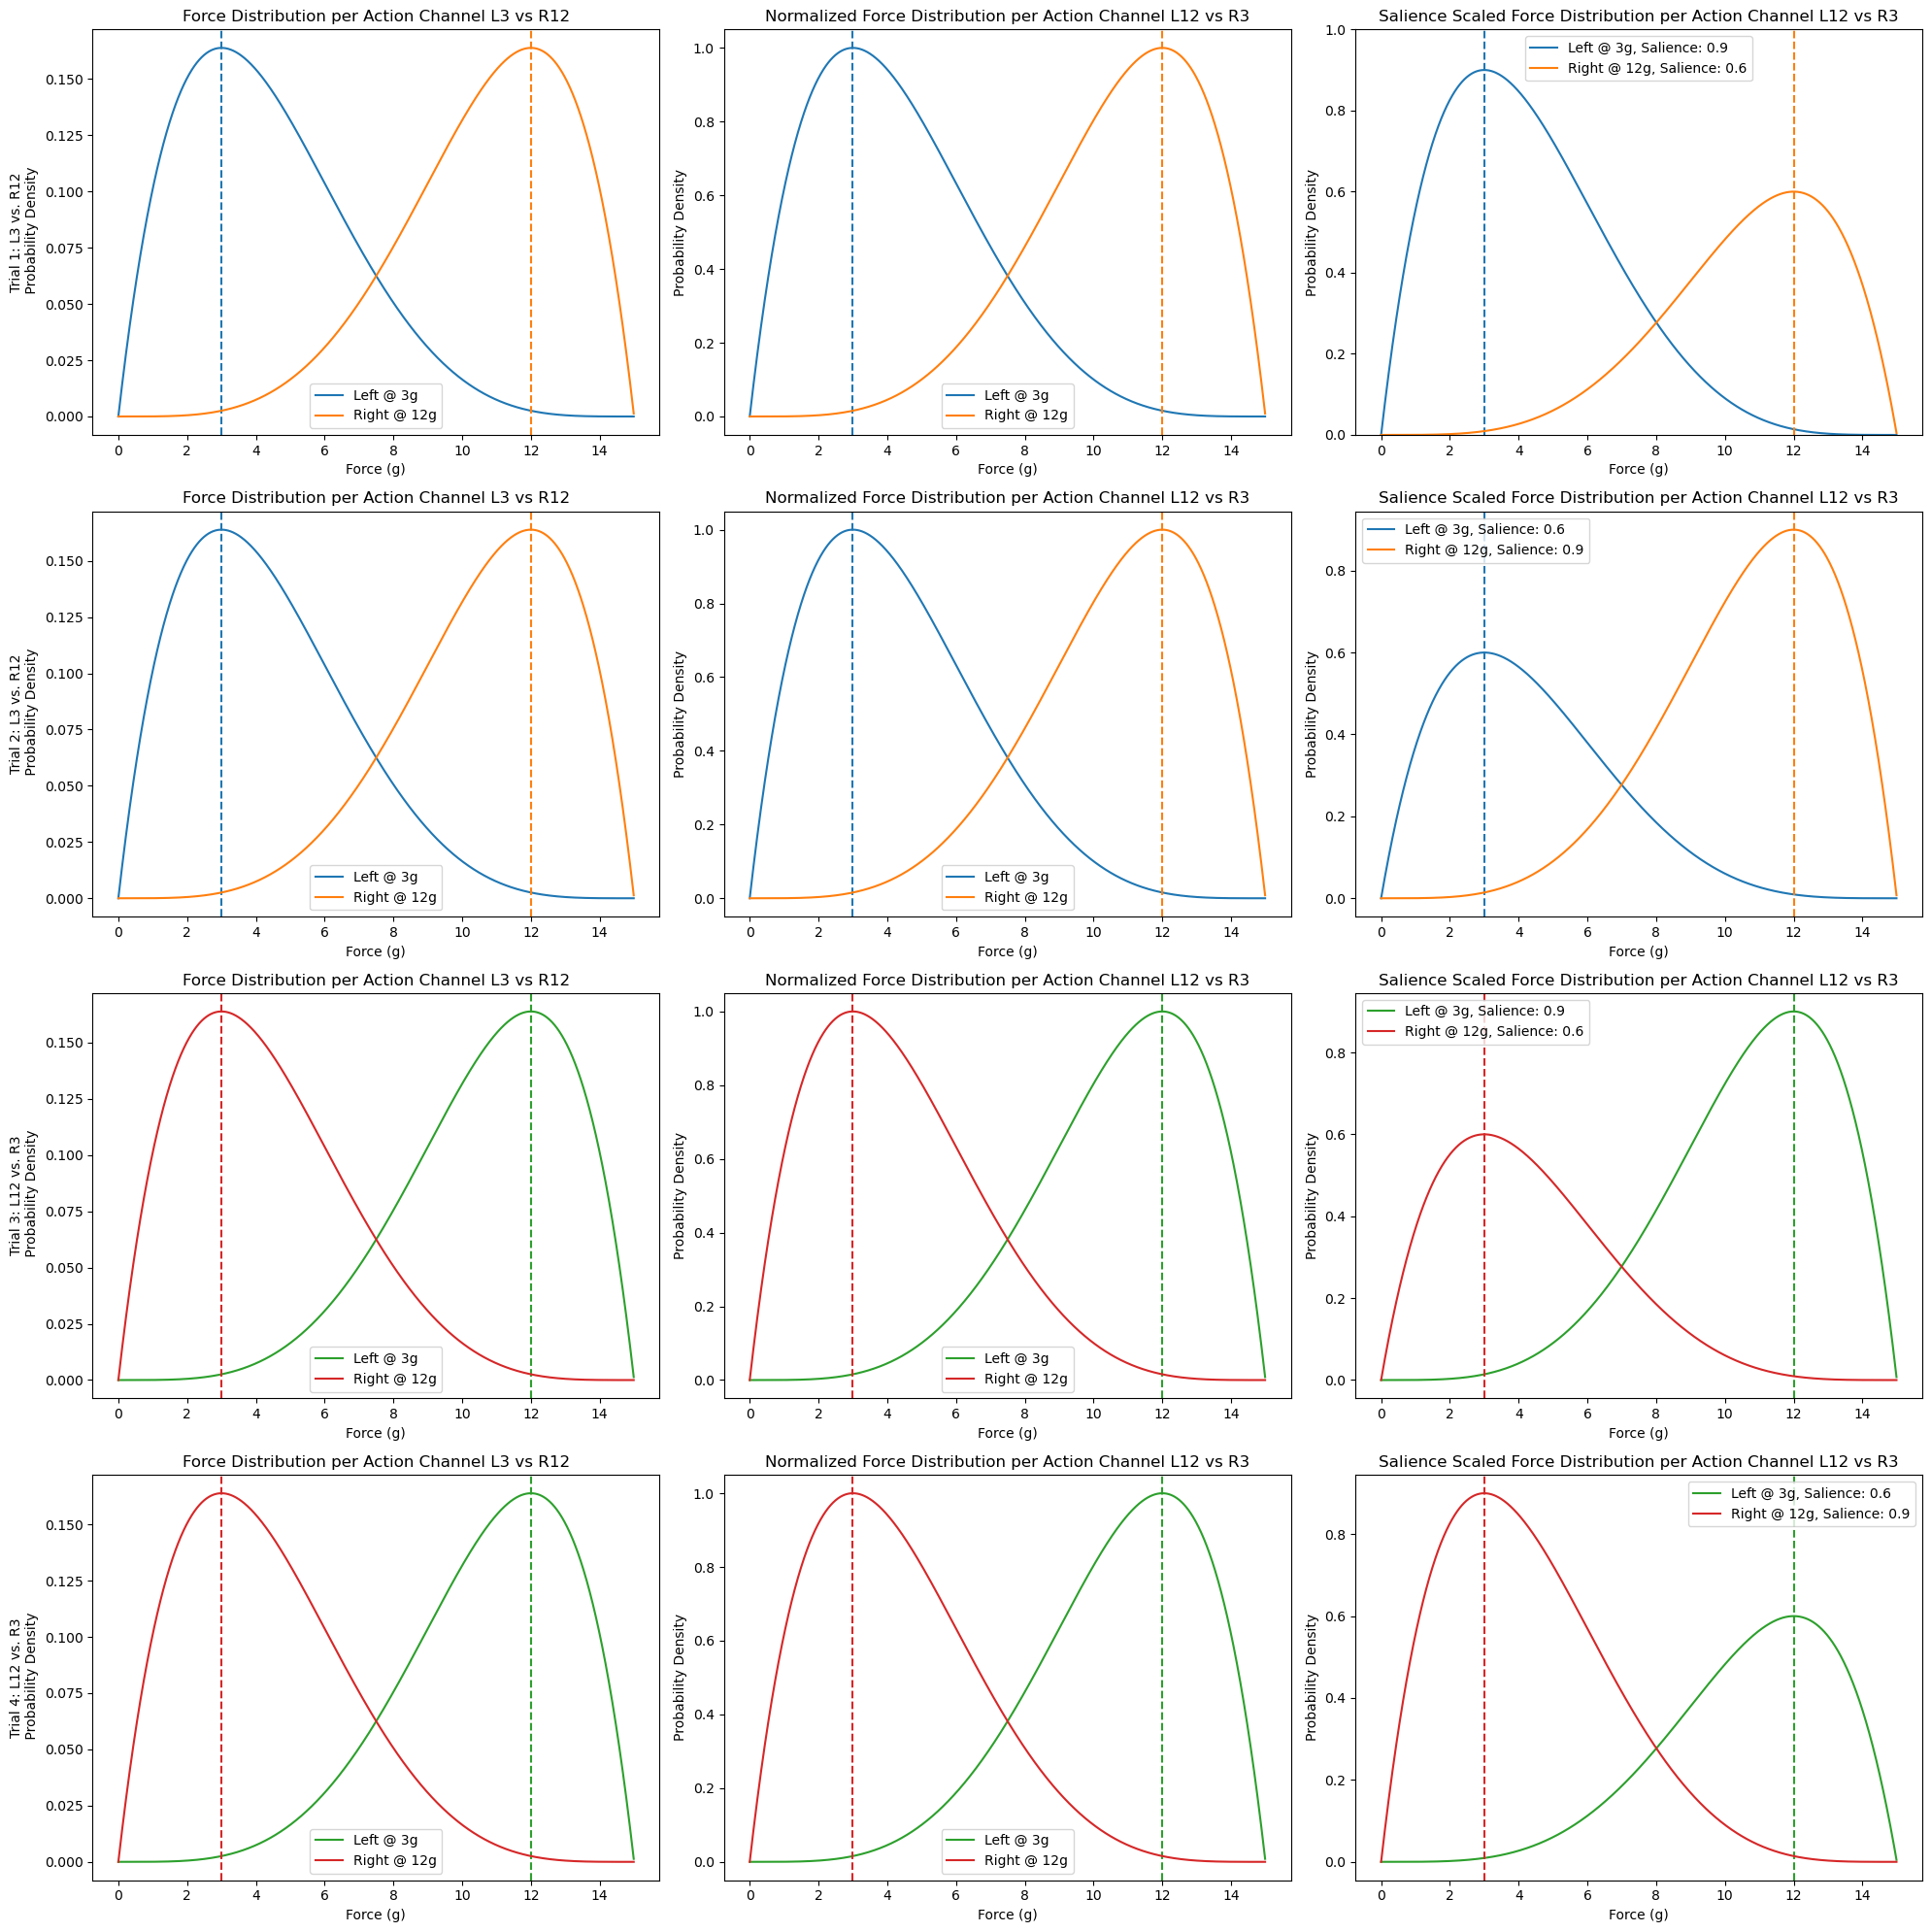

In [35]:
# ================================================
# 1. Define continuous force domain & SSP encoder
# ================================================
n_actions_park = 2
domain_force_park = np.arange(0, 15, 0.01).reshape(-1, 1) # Shape: (1500, 1)
ssp_dim_park = 512

# SSP encoder for scalar force values
ssp_encoder_park = RandomSSPSpace(
    domain_dim=1,
    ssp_dim=ssp_dim_park,
    rng=np.random.RandomState(0),
    length_scale=0.5
)
# Convert domain values to high-dimensional SSPs
domain_phis_park = ssp_encoder_park.encode(domain_force_park)  # shape: (1500, 512)
# print(domain_phis.shape)

# Place cell encoders for Nengo ensembles
low = 0
high = 15
width = high - low
places_park = np.arange(low, high, width/(domain_force_park.shape[0]))
dnf_encoders_park = np.asarray(ssp_encoder_park.encode(places_park.reshape(-1, 1))).squeeze() # Shape: (1500, 512)
# print(dnf_encoders.shape) # (512, 1500)

# ================================================
# 2. DNF Parameters
# ================================================
dnf_params_park = {
            'h'       : -3.009416816439706,
            'global_inh'      : 8.641108231311897,
            'tau'             : 0.04706404390267922,
            'exc'             : 9.421285790349613,
            'inh'             : 1.4841093480380807,
            'exc_w'           : 8.534993467227224,
            'inh_w'           : 4.748154014869723,
            'dt'              : 0.001, 
            'c_noise'         : 1.0,
            'shape'           : [(n_actions_park, 1500)], 
            'beta'            : 4,
    }


# ================================================
# 3. Generate two bundle vectors via Beta PDFs
#    Peaked at 3g and 12g respectively
# ================================================
# Beta shapes chosen so mode(a-1)/(a+b-2) matches desired peak/domain
# for 3g (mode 0.2*15=3), for 12g (mode 0.8*15=12) 
scale = 15
# Create the channel distributions for peak forces at 3g and 12g 
l3 = beta.pdf(domain_force_park.squeeze(), 2, 5, scale=scale) # Shape: 1500
r12 = beta.pdf(domain_force_park.squeeze(), 5, 2, scale=scale)
l12 = beta.pdf(domain_force_park.squeeze(), 5, 2, scale=scale)
r3 = beta.pdf(domain_force_park.squeeze(), 2, 5, scale=scale)
# Store the distributions 
beta_distributions_park = [l3, r12, l12, r3]

# ========================================
# 4. Salience values for actions
# ========================================
# Trial 1: Pull left (5˚, 3g) = 0.9, Pull right (-15˚, 12g) = 0.6
salience_t1 = [0.9, 0.6]
# Trial 2: Pull left (5˚, 3g) = 0.6, Pull right (-15˚, 12g) = 0.9
salience_t2 = [0.6, 0.9]
# Trial 3: Pull left (5˚, 12g) = 0.9, Pull right (-15˚, 3g) = 0.6
salience_t3 = [0.9, 0.6]
# Trial 4: Pull left (5˚, 12g) = 0.6, Pull right (-15˚, 3g) = 0.9
salience_t4 = [0.6, 0.9]


# ========================================
# 5. Create bundles for the 4 sets of trials 
# ========================================
# Trial 1: L3 vs. R12 
trial1 = Utility.to_bundle(Utility.to_scale(salience_t1, Utility.to_normalize([l3, r12])), domain_phis_park)
# Trial 1: L3 vs. R12 
trial2 = Utility.to_bundle(Utility.to_scale(salience_t2, Utility.to_normalize([l3, r12])), domain_phis_park)
# Trial 1: L12 vs. R3
trial3 = Utility.to_bundle(Utility.to_scale(salience_t3, Utility.to_normalize([l12, r3])), domain_phis_park)
# Trial 1: L12 vs. R3 
trial4 = Utility.to_bundle(Utility.to_scale(salience_t4, Utility.to_normalize([l12, r3])), domain_phis_park)
# All trials
trials = [trial1, trial2, trial3, trial4]

# ========================================
# 6. Plot the Beta distributions for each channel
# ========================================
colors_t1 = ['C0', 'C1']
colors_t2 = ['C2', 'C3']
actions = ['Left @ 3g', 'Right @ 12g']
peak_1 = [3, 12]
peak_2 = [12, 3]

# Plot the Bimodal distributions
# create 4×2 grid of subplots
fig, axes = plt.subplots(4, 3, figsize=(20, 20),)

# ---------------------------------
# Trial 1: L3 vs. R12 - L3 wins!
# ---------------------------------
# (0, 0): Distribution 
for i, pdf in enumerate([l3, r12]):
    axes[0, 0].plot(domain_force_park, pdf, color=colors_t1[i], label=f'{actions[i]}')
    axes[0, 0].axvline(peak_1[i], color=colors_t1[i], linestyle='--')
axes[0, 0].set_title('Force Distribution per Action Channel L3 vs R12')
axes[0, 0].set_xlabel('Force (g)')
axes[0, 0].set_ylabel('Probability Density')
axes[0, 0].legend()

# (0, 1): Normalized 
t1_normalized = Utility.to_normalize([l3, r12])
for i, pdf in enumerate(t1_normalized):
    axes[0, 1].plot(domain_force_park, pdf, color=colors_t1[i], label=f'{actions[i]}')
    axes[0, 1].axvline(peak_1[i], color=colors_t1[i], linestyle='--')
axes[0, 1].set_title('Normalized Force Distribution per Action Channel L12 vs R3')
axes[0, 1].set_xlabel('Force (g)')
axes[0, 1].set_ylabel('Probability Density')
axes[0, 1].legend()


# (0, 2): Salience scaled
t1_salience = Utility.to_scale(salience_t1, t1_normalized)
for i, pdf in enumerate(t1_salience):
    axes[0, 2].plot(domain_force_park, pdf, color=colors_t1[i], label=f'{actions[i]}, Salience: {salience_t1[i]}')
    axes[0, 2].axvline(peak_1[i], color=colors_t1[i], linestyle='--')
axes[0, 2].set_title('Salience Scaled Force Distribution per Action Channel L12 vs R3')
axes[0, 2].set_xlabel('Force (g)')
axes[0, 2].set_ylabel('Probability Density')
axes[0, 2].set_ylim(0, 1)
axes[0, 2].legend()

axes[0, 0].set_ylabel("Trial 1: L3 vs. R12\n Probability Density")

# ------------------------
# Trial 2: L3 vs. R12 - R12 wins!
# -----------------------
# (1, 0): Distribution 
for i, pdf in enumerate([l3, r12]):
    axes[1, 0].plot(domain_force_park, pdf, color=colors_t1[i], label=f'{actions[i]}')
    axes[1, 0].axvline(peak_1[i], color=colors_t1[i], linestyle='--')
axes[1, 0].set_title('Force Distribution per Action Channel L3 vs R12')
axes[1, 0].set_xlabel('Force (g)')
axes[1, 0].set_ylabel('Probability Density')
axes[1, 0].legend()

# (1, 1): Normalized 
t2_normalized = Utility.to_normalize([l3, r12])
for i, pdf in enumerate(t2_normalized):
    axes[1, 1].plot(domain_force_park, pdf, color=colors_t1[i], label=f'{actions[i]}')
    axes[1, 1].axvline(peak_1[i], color=colors_t1[i], linestyle='--')
axes[1, 1].set_title('Normalized Force Distribution per Action Channel L12 vs R3')
axes[1, 1].set_xlabel('Force (g)')
axes[1, 1].set_ylabel('Probability Density')
axes[1, 1].legend()

# (1, 2): Salience scaled
t2_salience = Utility.to_scale(salience_t2, t2_normalized)
for i, pdf in enumerate(t2_salience):
    axes[1, 2].plot(domain_force_park, pdf, color=colors_t1[i], label=f'{actions[i]}, Salience: {salience_t2[i]}')
    axes[1, 2].axvline(peak_1[i], color=colors_t1[i], linestyle='--')
axes[1, 2].set_title('Salience Scaled Force Distribution per Action Channel L12 vs R3')
axes[1, 2].set_xlabel('Force (g)')
axes[1, 2].set_ylabel('Probability Density')
axes[1, 2].legend()

axes[1, 0].set_ylabel("Trial 2: L3 vs. R12\n Probability Density")

# ------------------------
# Trial 3: L12 vs. R3 - L12 wins!
# -----------------------
# (2, 0): Distribution 
for i, pdf in enumerate([l12, r3]):
    axes[2, 0].plot(domain_force_park, pdf, color=colors_t2[i], label=f'{actions[i]}')
    axes[2, 0].axvline(peak_2[i], color=colors_t2[i], linestyle='--')
axes[2, 0].set_title('Force Distribution per Action Channel L3 vs R12')
axes[2, 0].set_xlabel('Force (g)')
axes[2, 0].set_ylabel('Probability Density')
axes[2, 0].legend()

# (2, 1): Normalized 
t3_normalized = Utility.to_normalize([l12, r3])
for i, pdf in enumerate(t3_normalized):
    axes[2, 1].plot(domain_force_park, pdf, color=colors_t2[i], label=f'{actions[i]}')
    axes[2, 1].axvline(peak_2[i], color=colors_t2[i], linestyle='--')
axes[2, 1].set_title('Normalized Force Distribution per Action Channel L12 vs R3')
axes[2, 1].set_xlabel('Force (g)')
axes[2, 1].set_ylabel('Probability Density')
axes[2, 1].legend()

# (2, 2): Salience scaled
t3_salience = Utility.to_scale(salience_t3, t3_normalized)
for i, pdf in enumerate(t3_salience):
    axes[2, 2].plot(domain_force_park, pdf, color=colors_t2[i], label=f'{actions[i]}, Salience: {salience_t3[i]}')
    axes[2, 2].axvline(peak_2[i], color=colors_t2[i], linestyle='--')
axes[2, 2].set_title('Salience Scaled Force Distribution per Action Channel L12 vs R3')
axes[2, 2].set_xlabel('Force (g)')
axes[2, 2].set_ylabel('Probability Density')
axes[2, 2].legend()

axes[2, 0].set_ylabel("Trial 3: L12 vs. R3\n Probability Density")

# ------------------------
# Trial 4: L12 vs. R3 - R3 wins!
# -----------------------
# (3, 0): Distribution 
for i, pdf in enumerate([l12, r3]):
    axes[3, 0].plot(domain_force_park, pdf, color=colors_t2[i], label=f'{actions[i]}')
    axes[3, 0].axvline(peak_2[i], color=colors_t2[i], linestyle='--')
axes[3, 0].set_title('Force Distribution per Action Channel L3 vs R12')
axes[3, 0].set_xlabel('Force (g)')
axes[3, 0].set_ylabel('Probability Density')
axes[3, 0].legend()

# (1, 1): Normalized 
t4_normalized = Utility.to_normalize([l12, r3])
for i, pdf in enumerate(t4_normalized):
    axes[3, 1].plot(domain_force_park, pdf, color=colors_t2[i], label=f'{actions[i]}')
    axes[3, 1].axvline(peak_2[i], color=colors_t2[i], linestyle='--')
axes[3, 1].set_title('Normalized Force Distribution per Action Channel L12 vs R3')
axes[3, 1].set_xlabel('Force (g)')
axes[3, 1].set_ylabel('Probability Density')
axes[3, 1].legend()

# (1, 2): Salience scaled
t4_salience = Utility.to_scale(salience_t4, t4_normalized)
for i, pdf in enumerate(t4_salience):
    axes[3, 2].plot(domain_force_park, pdf, color=colors_t2[i], label=f'{actions[i]}, Salience: {salience_t4[i]}')
    axes[3, 2].axvline(peak_2[i], color=colors_t2[i], linestyle='--')
axes[3, 2].set_title('Salience Scaled Force Distribution per Action Channel L12 vs R3')
axes[3, 2].set_xlabel('Force (g)')
axes[3, 2].set_ylabel('Probability Density')
axes[3, 2].legend()

axes[3, 0].set_ylabel("Trial 4: L12 vs. R3\n Probability Density")

plt.tight_layout()
plt.savefig('./figures/park/unimodal/park_distribution.png')
plt.show()

# Conduct Trials

In [36]:
# Run the trials and collect data 

def trial(bundles, n_actions, dnf_parameters, encoders, ssp_size = 512, d1_weight = 1.0, d2_weight = 1.0, dopamine_level = 0.2):
    assert len(bundles) == n_actions, "The number of input bundles and action channels is not the same"
    # DNF/BG Parameters
    d1_weight = d1_weight
    d2_weight = d2_weight
    dopamine_level = dopamine_level
    
    # Basal Ganglia model
    bg_model = BasalGanglia(n_actions=n_actions, dnf_parameters=dnf_params_park, encoders=encoders, dnf_neurons = 1500)
    data = bg_model.simulate(input_bundles=bundles, dopamine_level=dopamine_level, presentation_time=1.5, duration=1.5)
    return data


# Run the 4 trials
run_trial1 = trial(trial1, n_actions=2, dnf_parameters = dnf_params_park, encoders=dnf_encoders_park)
run_trial2 = trial(trial2, n_actions=2, dnf_parameters = dnf_params_park, encoders=dnf_encoders_park)
run_trial3 = trial(trial3, n_actions=2, dnf_parameters = dnf_params_park, encoders=dnf_encoders_park)
run_trial4 = trial(trial4, n_actions=2, dnf_parameters = dnf_params_park, encoders=dnf_encoders_park)

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

/Users/priyadarshinisaha/anaconda3/envs/bgmodel/lib/python3.10/site-packages/nengo/neurons.py:489: RuntimeWarning: overflow encountered in exp
  output[...] = (1.0 / self.tau_ref) / (1 + np.exp(-J))


HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

# Generate Plots

## Input Bundle Plots vs. Original Beta Distributions

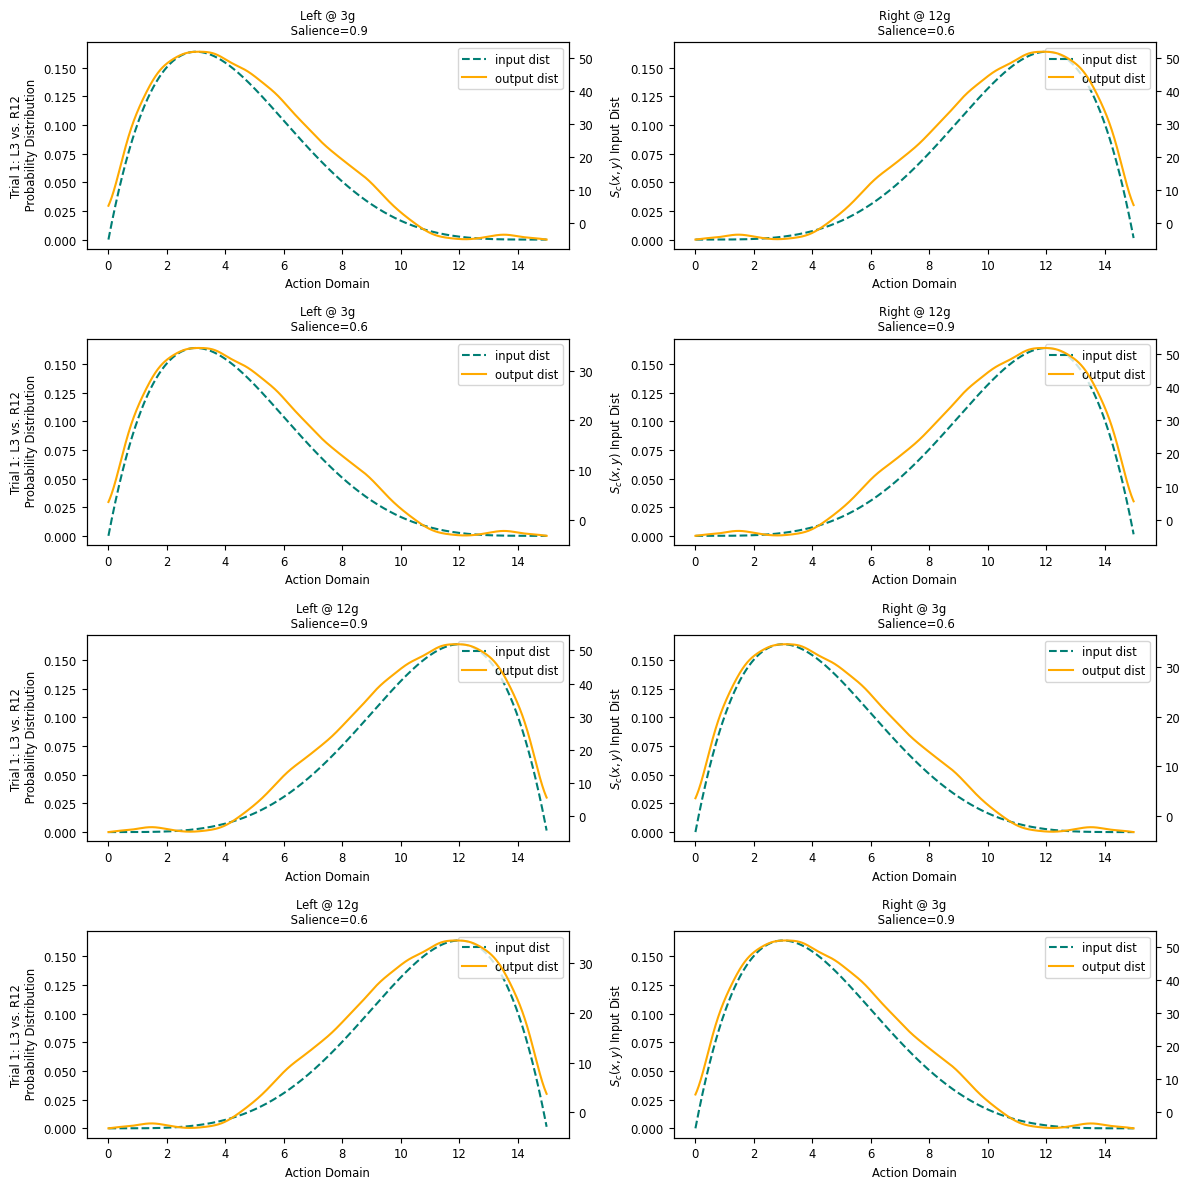

In [37]:
def plot_input_bundles(org_dist, bundle_dist, axes, trial_int, action_labels, salience_plot):
    ax = axes[trial_int]
    for i in range(n_actions_park):
        # Primary y-axis: input distribution
        ax[i].plot(domain_force_park.squeeze(), org_dist[i], ls='--', color="#007e74", label="input dist")
        ax[i].set_xlabel("Action Domain", fontsize="small")
        ax[i].set_ylabel("$S_c(x,y)$ Input Dist", fontsize="small")
        ax[i].tick_params(axis='x', labelsize='small')
        ax[i].tick_params(axis='y', labelsize='small')

        ax2 = ax[i].twinx()
        ax2.plot(domain_force_park.squeeze(), bundle_dist[i],
                 ls='-', color="#ffaa00", label="output dist")
        ax2.tick_params(axis='y', labelsize='small')

        # Combined legend
        h1, l1 = ax[i].get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        ax[i].legend(h1 + h2, l1 + l2, loc='upper right', fontsize='small')

        ax[i].set_title(f'{action_labels[i]}\n Salience={salience_plot[i]}', fontsize='small')
    axes[trial_int, 0].set_ylabel("Trial 1: L3 vs. R12\n Probability Distribution")




# Create a 4 x 2 grid 
fig, axes = plt.subplots(4, 2, figsize=(12, 12))

# Trail 1 
bin_l3_dist1 = np.einsum('d,nd->n', run_trial1['bundle_ins'][0][-1], domain_phis_park)
bin_r12_dist1 = np.einsum('d,nd->n', run_trial1['bundle_ins'][1][-1], domain_phis_park)

# Trial 2
bin_l3_dist2 = np.einsum('d,nd->n', run_trial2['bundle_ins'][0][-1], domain_phis_park)
bin_r12_dist2 = np.einsum('d,nd->n', run_trial2['bundle_ins'][1][-1], domain_phis_park)

# Trial 3
bin_l12_dist3 = np.einsum('d,nd->n', run_trial3['bundle_ins'][0][-1], domain_phis_park)
bin_r3_dist3 = np.einsum('d,nd->n', run_trial3['bundle_ins'][1][-1], domain_phis_park)

# Trial 4
bin_l12_dist4 = np.einsum('d,nd->n', run_trial4['bundle_ins'][0][-1], domain_phis_park)
bin_r3_dist4 = np.einsum('d,nd->n', run_trial4['bundle_ins'][1][-1], domain_phis_park)

if n_actions_park == 1:
    axes = [axes]

plot_input_bundles([l3, r12], [bin_l3_dist1, bin_r12_dist2], axes, trial_int = 0, action_labels=['Left @ 3g', 'Right @ 12g'], salience_plot=salience_t1)
plot_input_bundles([l3, r12], [bin_l3_dist2, bin_r12_dist2], axes, trial_int = 1, action_labels=['Left @ 3g', 'Right @ 12g'], salience_plot=salience_t2)
plot_input_bundles([l12, r3], [bin_l12_dist3, bin_r3_dist3], axes, trial_int = 2, action_labels=['Left @ 12g', 'Right @ 3g'], salience_plot=salience_t3)
plot_input_bundles([l12, r3], [bin_l12_dist4, bin_r3_dist4], axes, trial_int = 3, action_labels=['Left @ 12g', 'Right @ 3g'], salience_plot=salience_t4)
plt.tight_layout()
plt.savefig('./figures/park/unimodal/input_bundles_park.png')
plt.show()




## DNF - D1 & D2 

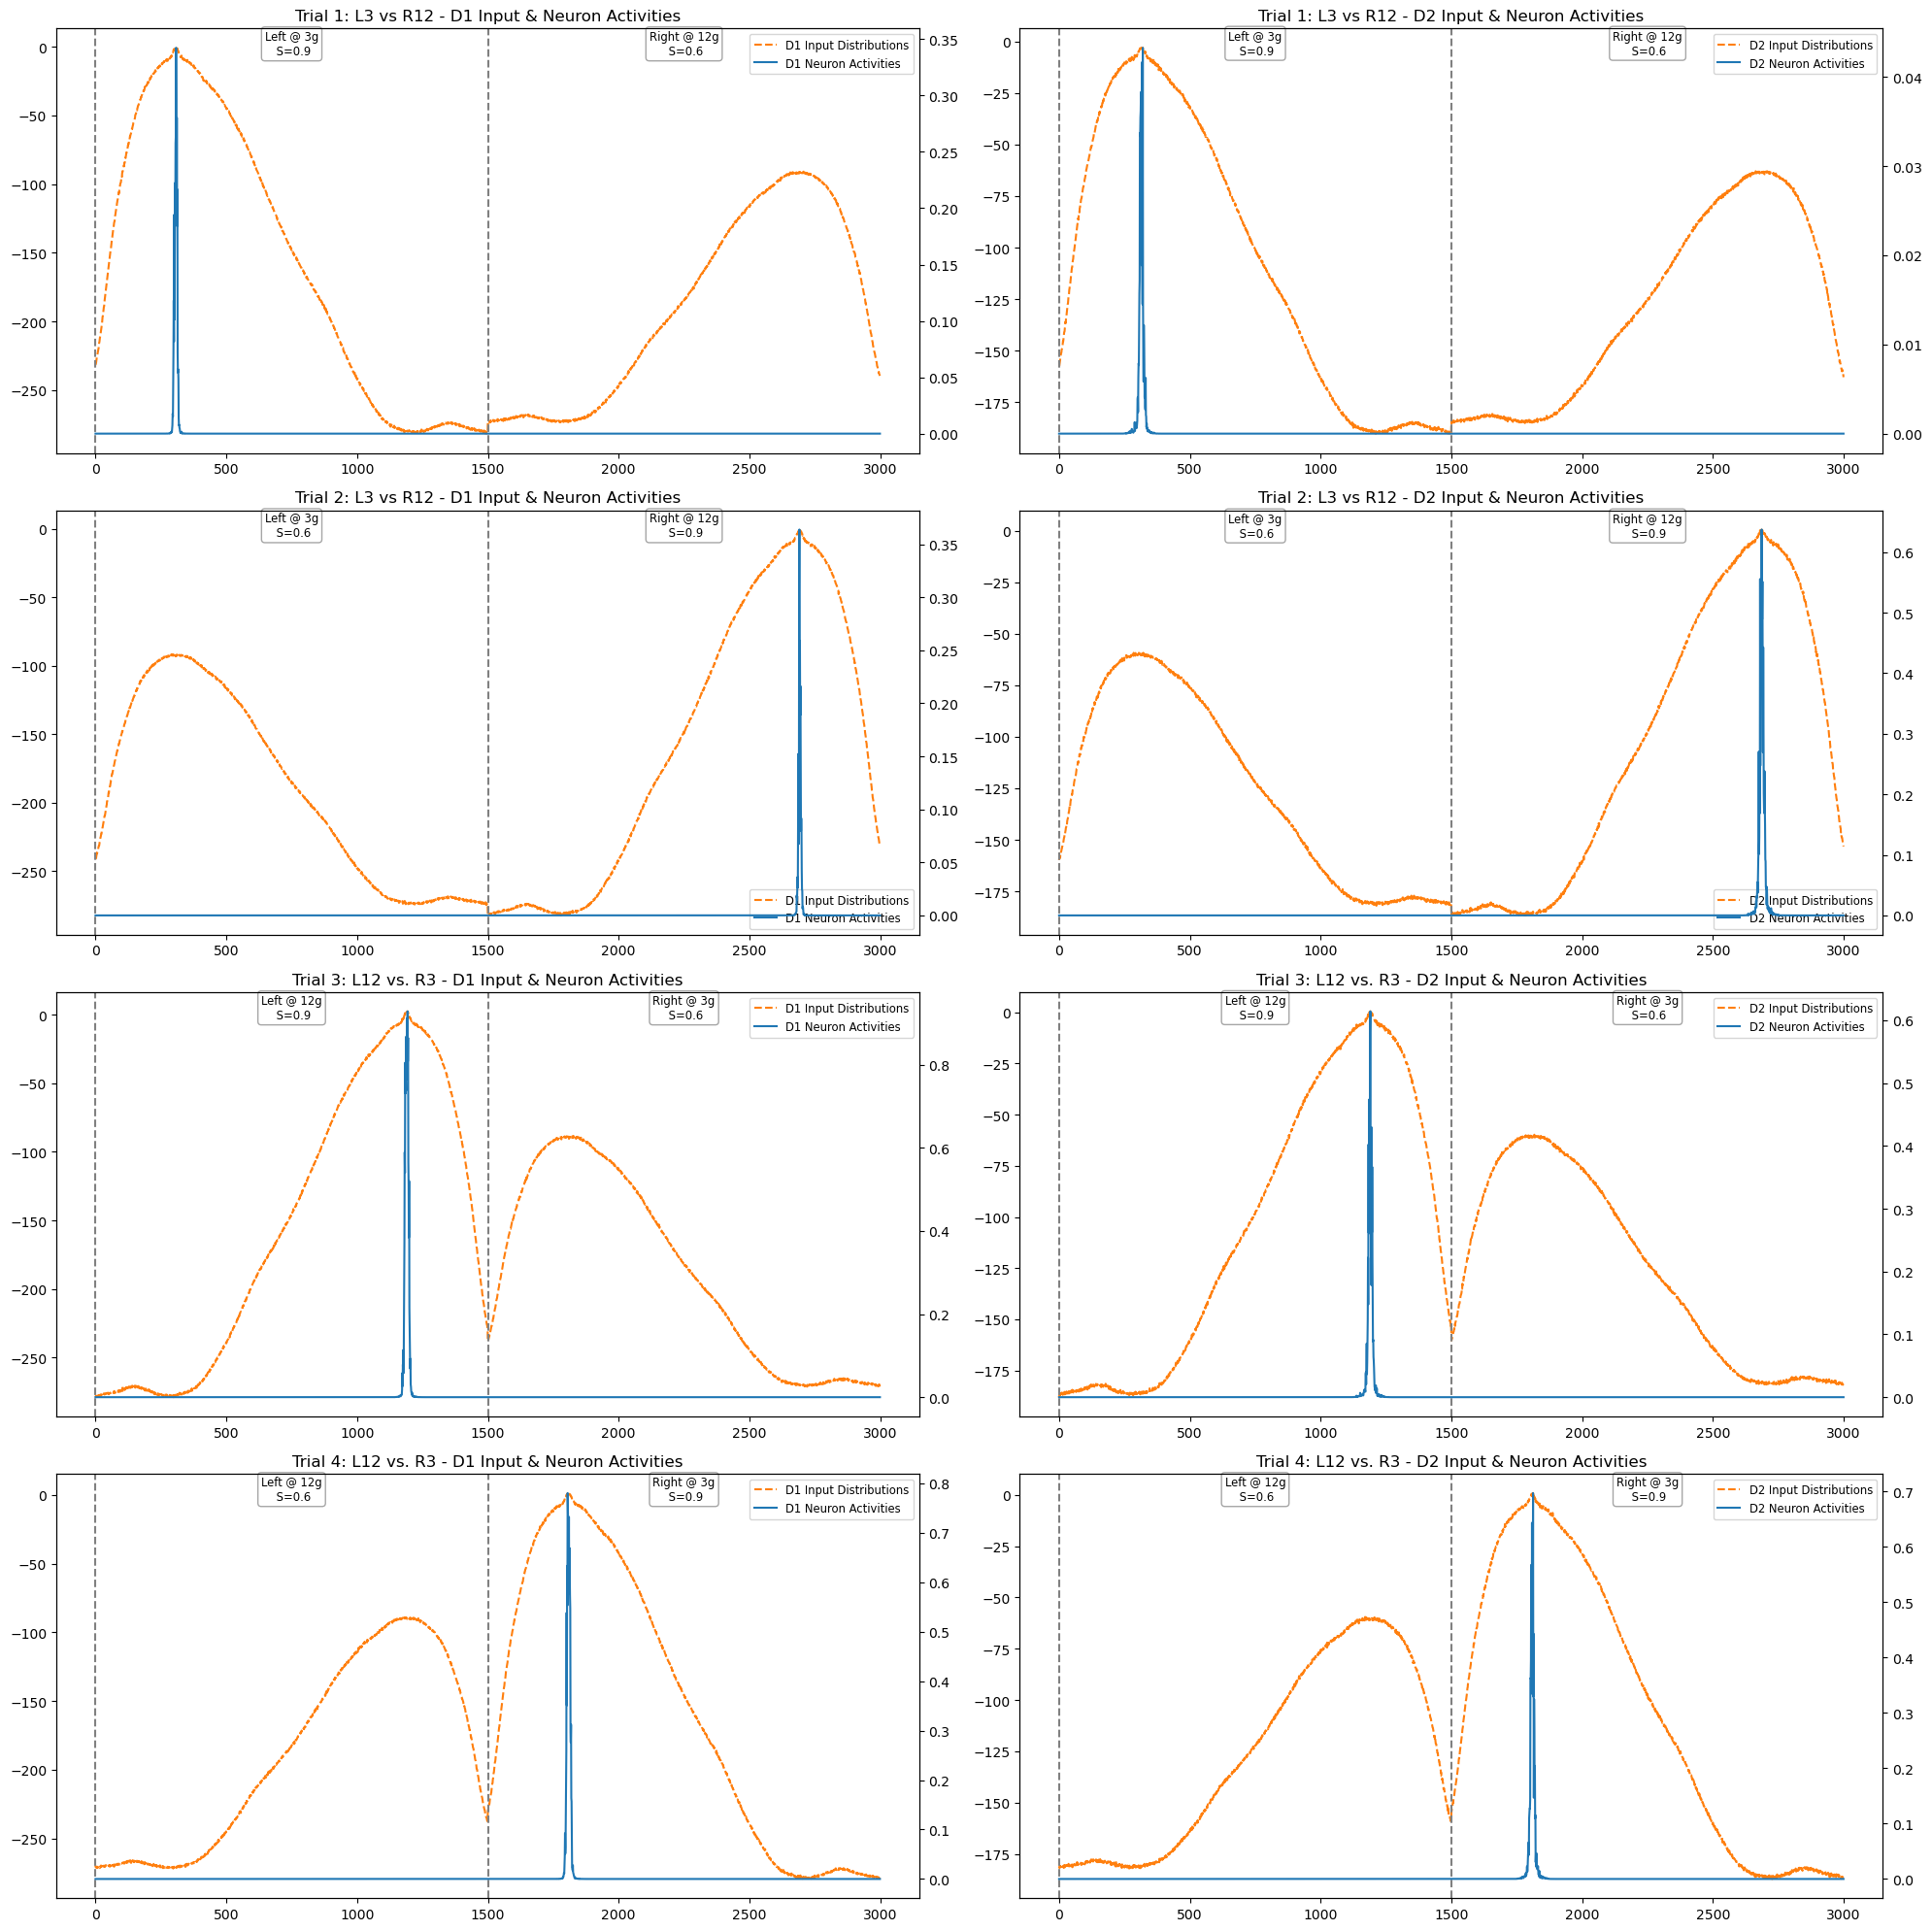

In [38]:
# Plot D1 and D2 on a 4 x 1 grid with neuron activities and DNF Input 

fig, axes = plt.subplots(4, 2, figsize=(20, 20))
trial_labels = ['L3 vs R12', 'L3 vs R12', 'L12 vs. R3', 'L12 vs. R3']
data_trials = [run_trial1, run_trial2, run_trial3, run_trial4]
action_labels = [
    ['Left @ 3g', 'Right @ 12g'], # Trial 1
    ['Left @ 3g', 'Right @ 12g'], # Trial 2
    ['Left @ 12g', 'Right @ 3g'], # Trial 3
    ['Left @ 12g', 'Right @ 3g'], # Trial 4
]

salience_labels = [salience_t1, salience_t2, salience_t3, salience_t4]

# Trial 1: L3 vs R12 - L3 wins 
for i in range(4):
    # For D1
    # Primary axis for Input
    axes[i, 0].plot(data_trials[i]['d1_input'][-1], label='D1 Input Distributions', linestyle='--', color='C1')
    # Secondary axis for neuron activities
    ax2 = axes[i, 0].twinx()
    ax2.plot(data_trials[i]['d1_neuron'][-1], label='D1 Neuron Activities')
    # Combined legend
    h1, l1 = axes[i, 0].get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    axes[i, 0].legend(h1 + h2, l1 + l2, loc='best', fontsize='small')
    axes[i, 0].set_title(f'Trial {i + 1}: {trial_labels[i]} - D1 Input & Neuron Activities')
    # For D2
    # Primary axis for Input
    axes[i, 1].plot(data_trials[i]['d2_input'][-1], label='D2 Input Distributions', linestyle='--', color='C1')
    # Secondary axis for neuron activities
    ax3 = axes[i, 1].twinx()
    ax3.plot(data_trials[i]['d2_neuron'][-1], label='D2 Neuron Activities')
    # Combined legend
    h3, l3 = axes[i, 1].get_legend_handles_labels()
    h4, l4 = ax3.get_legend_handles_labels()
    axes[i, 1].legend(h3 + h4, l3 + l4, loc='best', fontsize='small')
    axes[i, 1].set_title(f'Trial {i + 1}: {trial_labels[i]} - D2 Input & Neuron Activities')

# Add channel seperation lines and text 
for i in range(n_actions_park):
    for j in range(4):
        xpos = i * domain_force_park.shape[0]
        axes[j, 0].axvline(xpos, linestyle='--', color='grey')
        axes[j, 1].axvline(xpos, linestyle='--', color='grey')
        # Compute the center between this and the next section
        if i < n_actions_park - 1:
            next_xpos = (i + 1) * domain_force_park.shape[0]
            x_text = (xpos + next_xpos) / 2
        else:
            # For the last section, center in the last segment
            x_text = xpos + domain_force_park.shape[0] / 2
        # Place text near the top of the plot
        y_text = axes[j, 0].get_ylim()[1] * 0.90  # 90% up the y-axis
        axes[j, 0].text(
            x_text, y_text,
            f"{action_labels[j][i]}\n S={salience_labels[j][i]:.1f}",
            ha='center', va='top',
            fontsize='small',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7)
        )
        y_text2 = axes[j, 1].get_ylim()[1] * 0.90  # 90% up the y-axis
        axes[j, 1].text(
            x_text, y_text2,
            f"{action_labels[j][i]}\n S={salience_labels[j][i]:.1f}",
            ha='center', va='top',
            fontsize='small',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7)
        )
plt.tight_layout()
plt.savefig('./figures/park/unimodal/park_dnf.png')
plt.show()


## Input Vs. Output Distributions

(3000,)


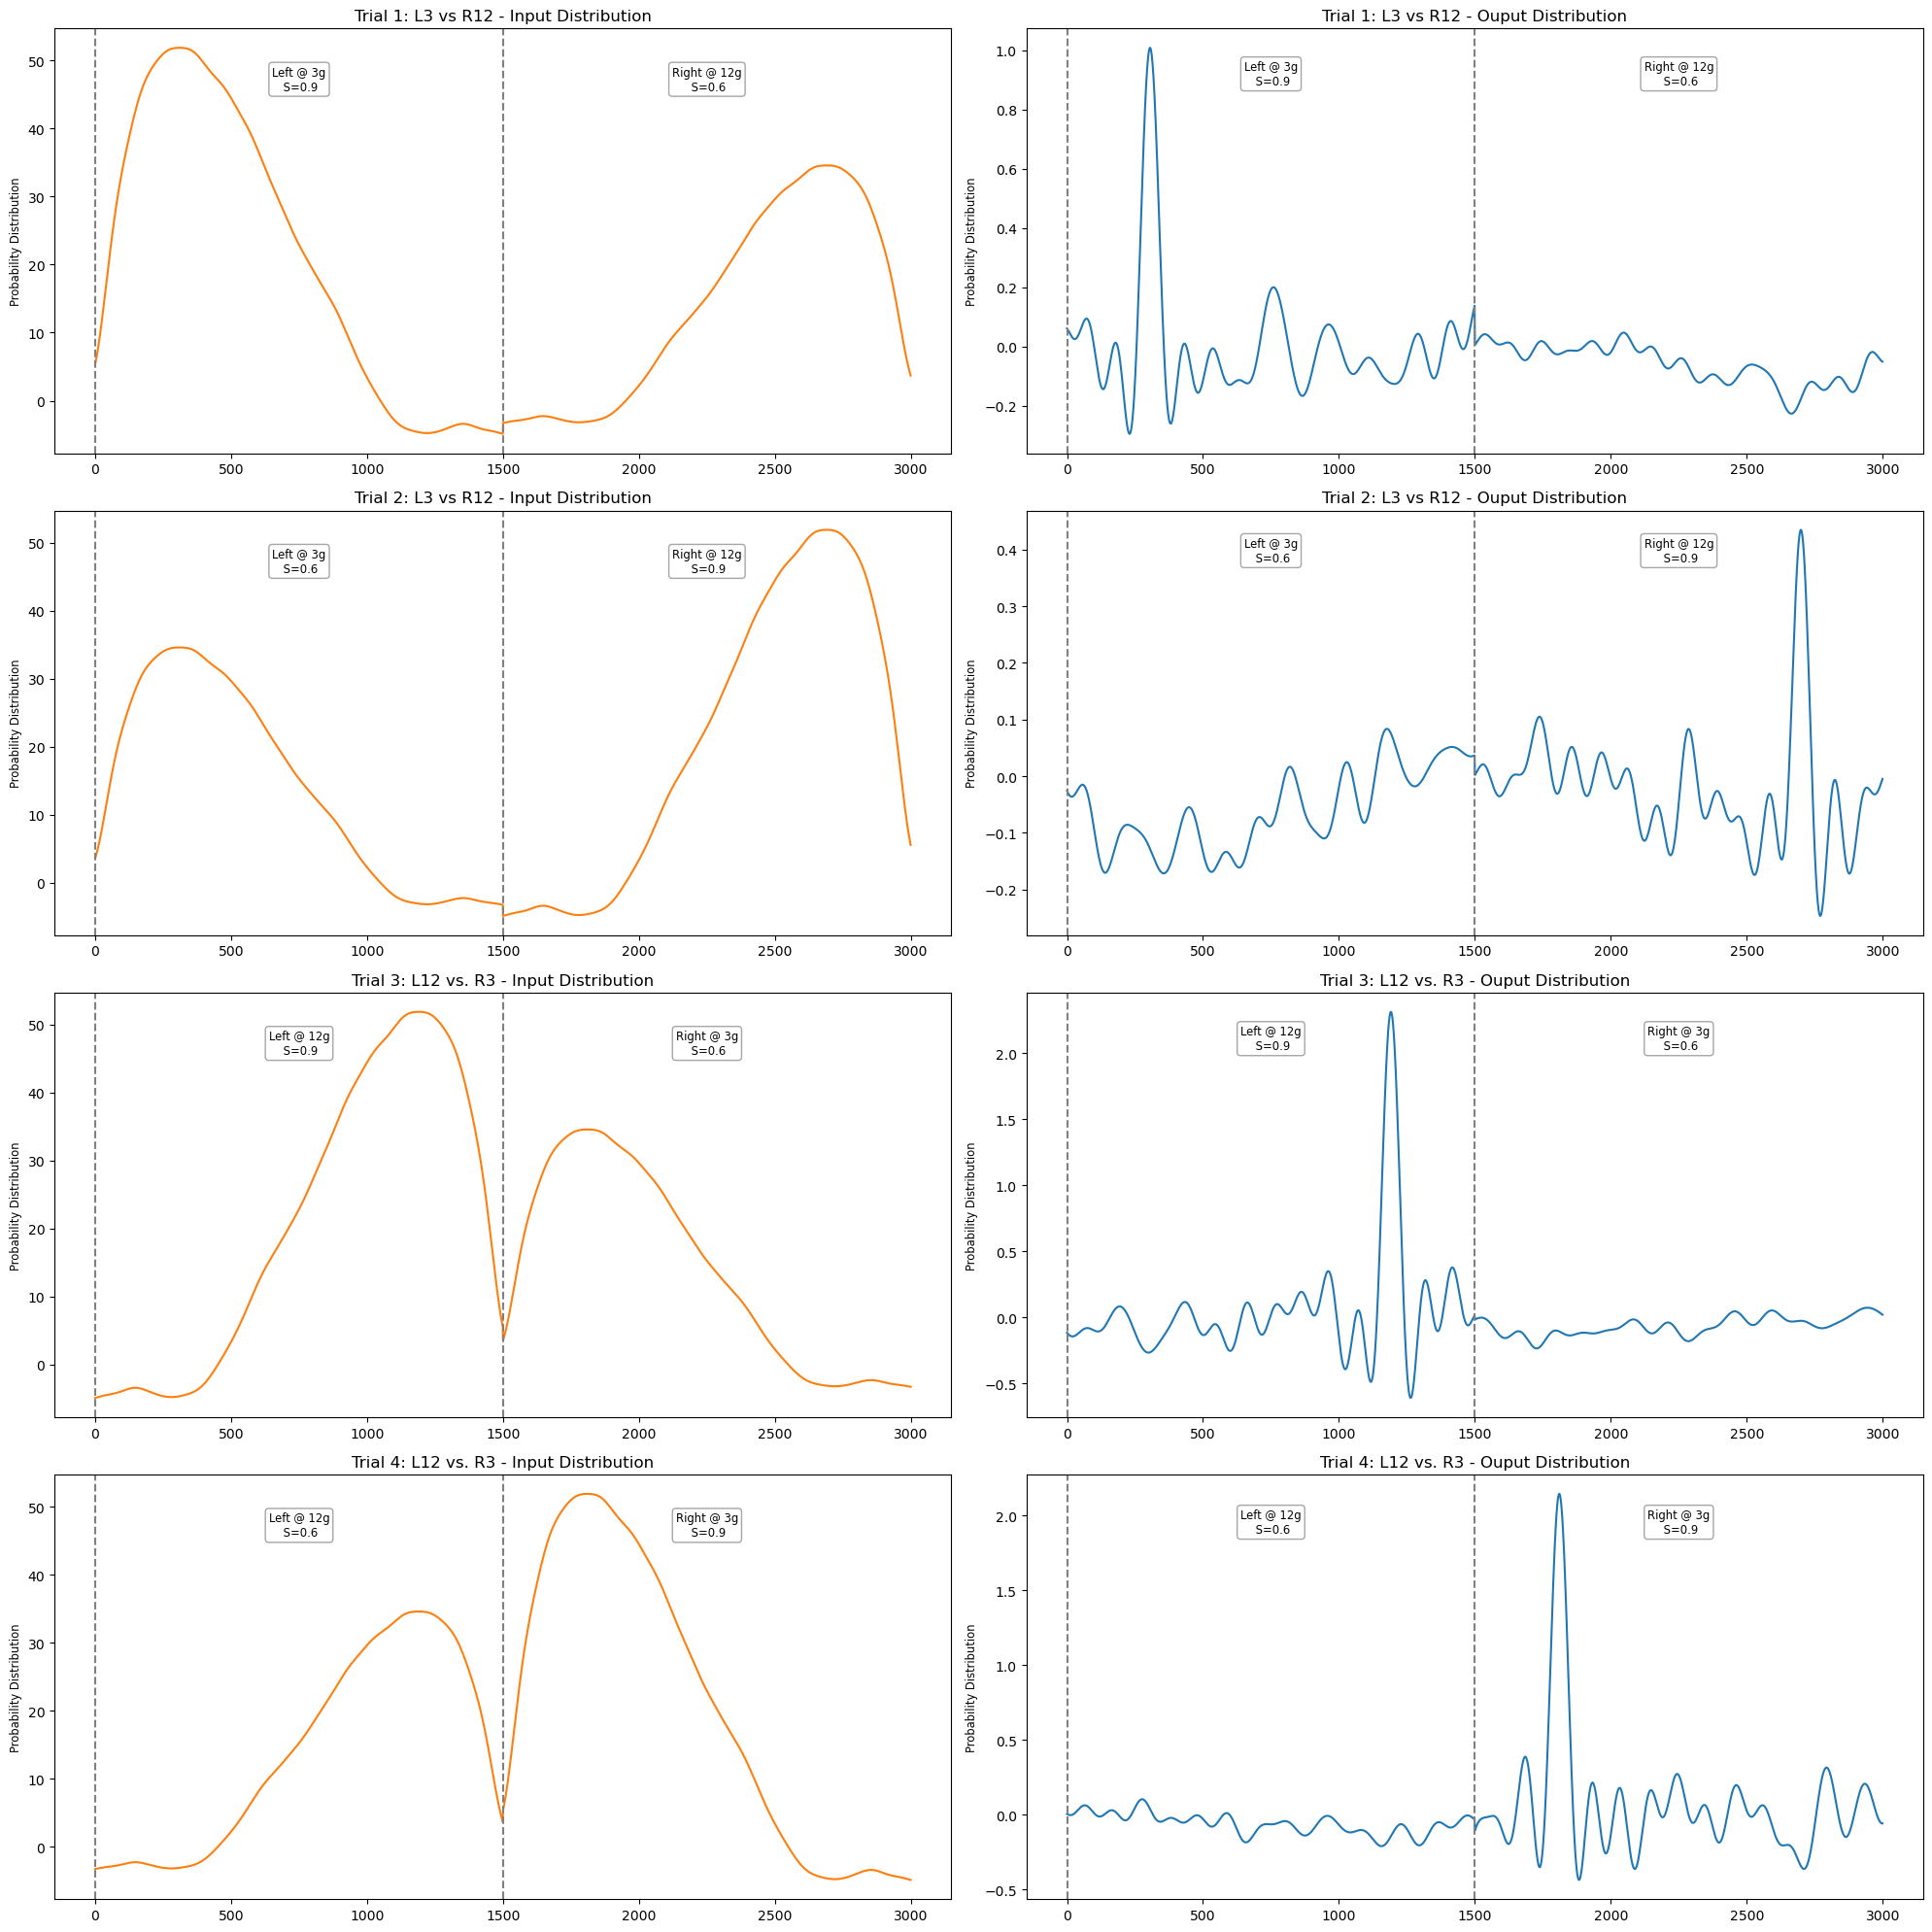

In [39]:
# Plot Input and Output Distribution 

fig, axes = plt.subplots(4, 2, figsize=(20, 20))
trial_labels = ['L3 vs R12', 'L3 vs R12', 'L12 vs. R3', 'L12 vs. R3']
action_labels = [
    ['Left @ 3g', 'Right @ 12g'], # Trial 1
    ['Left @ 3g', 'Right @ 12g'], # Trial 2
    ['Left @ 12g', 'Right @ 3g'], # Trial 3
    ['Left @ 12g', 'Right @ 3g'], # Trial 4
]

salience_labels = [salience_t1, salience_t2, salience_t3, salience_t4]

# for each trial convert the bundle in and bundle out to distributions
# Trail 1 
bin_l3_dist1 = np.einsum('d,nd->n', run_trial1['bundle_ins'][0][-1], domain_phis_park)
bin_r12_dist1 = np.einsum('d,nd->n', run_trial1['bundle_ins'][1][-1], domain_phis_park)
bout_l3_dist1 = np.einsum('d,nd->n', run_trial1['bundle_out'][-1][0: 512], domain_phis_park)
bout_r12_dist1 = np.einsum('d,nd->n', run_trial1['bundle_out'][-1][512:], domain_phis_park)

# Trial 2
bin_l3_dist2 = np.einsum('d,nd->n', run_trial2['bundle_ins'][0][-1], domain_phis_park)
bin_r12_dist2 = np.einsum('d,nd->n', run_trial2['bundle_ins'][1][-1], domain_phis_park)
bout_l3_dist2 = np.einsum('d,nd->n', run_trial2['bundle_out'][-1][0: 512], domain_phis_park)
bout_r12_dist2 = np.einsum('d,nd->n', run_trial2['bundle_out'][-1][512:], domain_phis_park)

# Trial 3
bin_l12_dist3 = np.einsum('d,nd->n', run_trial3['bundle_ins'][0][-1], domain_phis_park)
bin_r3_dist3 = np.einsum('d,nd->n', run_trial3['bundle_ins'][1][-1], domain_phis_park)
bout_l12_dist3 = np.einsum('d,nd->n', run_trial3['bundle_out'][-1][0: 512], domain_phis_park)
bout_r3_dist3 = np.einsum('d,nd->n', run_trial3['bundle_out'][-1][512:], domain_phis_park)

# Trial 4
bin_l12_dist4 = np.einsum('d,nd->n', run_trial4['bundle_ins'][0][-1], domain_phis_park)
bin_r3_dist4 = np.einsum('d,nd->n', run_trial4['bundle_ins'][1][-1], domain_phis_park)
bout_l12_dist4 = np.einsum('d,nd->n', run_trial4['bundle_out'][-1][0: 512], domain_phis_park)
bout_r3_dist4 = np.einsum('d,nd->n', run_trial4['bundle_out'][-1][512:], domain_phis_park)

bundle_in_park = [
    np.hstack([bin_l3_dist1, bin_r12_dist1]), # Trial 1
    np.hstack([bin_l3_dist2, bin_r12_dist2]), # Trial 2
    np.hstack([bin_l12_dist3, bin_r3_dist3]), # Trial 3
    np.hstack([bin_l12_dist4, bin_r3_dist4]), # Trial 4

]

bundle_out_park = [
    np.hstack([bout_l3_dist1, bout_r12_dist1]), # Trial 1
    np.hstack([bout_l3_dist2, bout_r12_dist2]), # Trial 2
    np.hstack([bout_l12_dist3, bout_r3_dist3]), # Trial 3
    np.hstack([bout_l12_dist4, bout_r3_dist4]), # Trial 4
]

print(bundle_out_park[0].shape)
for i in range(4):
    # For Input Distribution 
    # Primary axis for Input
    axes[i, 0].plot(bundle_in_park[i], label='Input Distributions', color='C1')
    axes[i, 0].set_title(f'Trial {i + 1}: {trial_labels[i]} - Input Distribution')
    axes[i, 0].set_ylabel('Probability Distribution', fontsize='small')
    axes[i, 1].plot(bundle_out_park[i], label='Ouput Distributions', color='C0')
    axes[i, 1].set_title(f'Trial {i + 1}: {trial_labels[i]} - Ouput Distribution')
    axes[i, 1].set_ylabel('Probability Distribution', fontsize='small')
    # Secondary axis for neuron activities

# Add channel seperation lines and text 
for i in range(n_actions_park):
    for j in range(4):
        xpos = i * domain_force_park.shape[0]
        axes[j, 0].axvline(xpos, linestyle='--', color='grey')
        axes[j, 1].axvline(xpos, linestyle='--', color='grey')
        # Compute the center between this and the next section
        if i < n_actions_park - 1:
            next_xpos = (i + 1) * domain_force_park.shape[0]
            x_text = (xpos + next_xpos) / 2
        else:
            # For the last section, center in the last segment
            x_text = xpos + domain_force_park.shape[0] / 2
        # Place text near the top of the plot
        y_text = axes[j, 0].get_ylim()[1] * 0.90  # 90% up the y-axis
        axes[j, 0].text(
            x_text, y_text,
            f"{action_labels[j][i]}\n S={salience_labels[j][i]:.1f}",
            ha='center', va='top',
            fontsize='small',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7)
        )
        y_text2 = axes[j, 1].get_ylim()[1] * 0.90  # 90% up the y-axis
        axes[j, 1].text(
            x_text, y_text2,
            f"{action_labels[j][i]}\n S={salience_labels[j][i]:.1f}",
            ha='center', va='top',
            fontsize='small',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7)
        )
plt.tight_layout()
plt.savefig('./figures/park/unimodal/park_in_out_distribution.png')
plt.show()


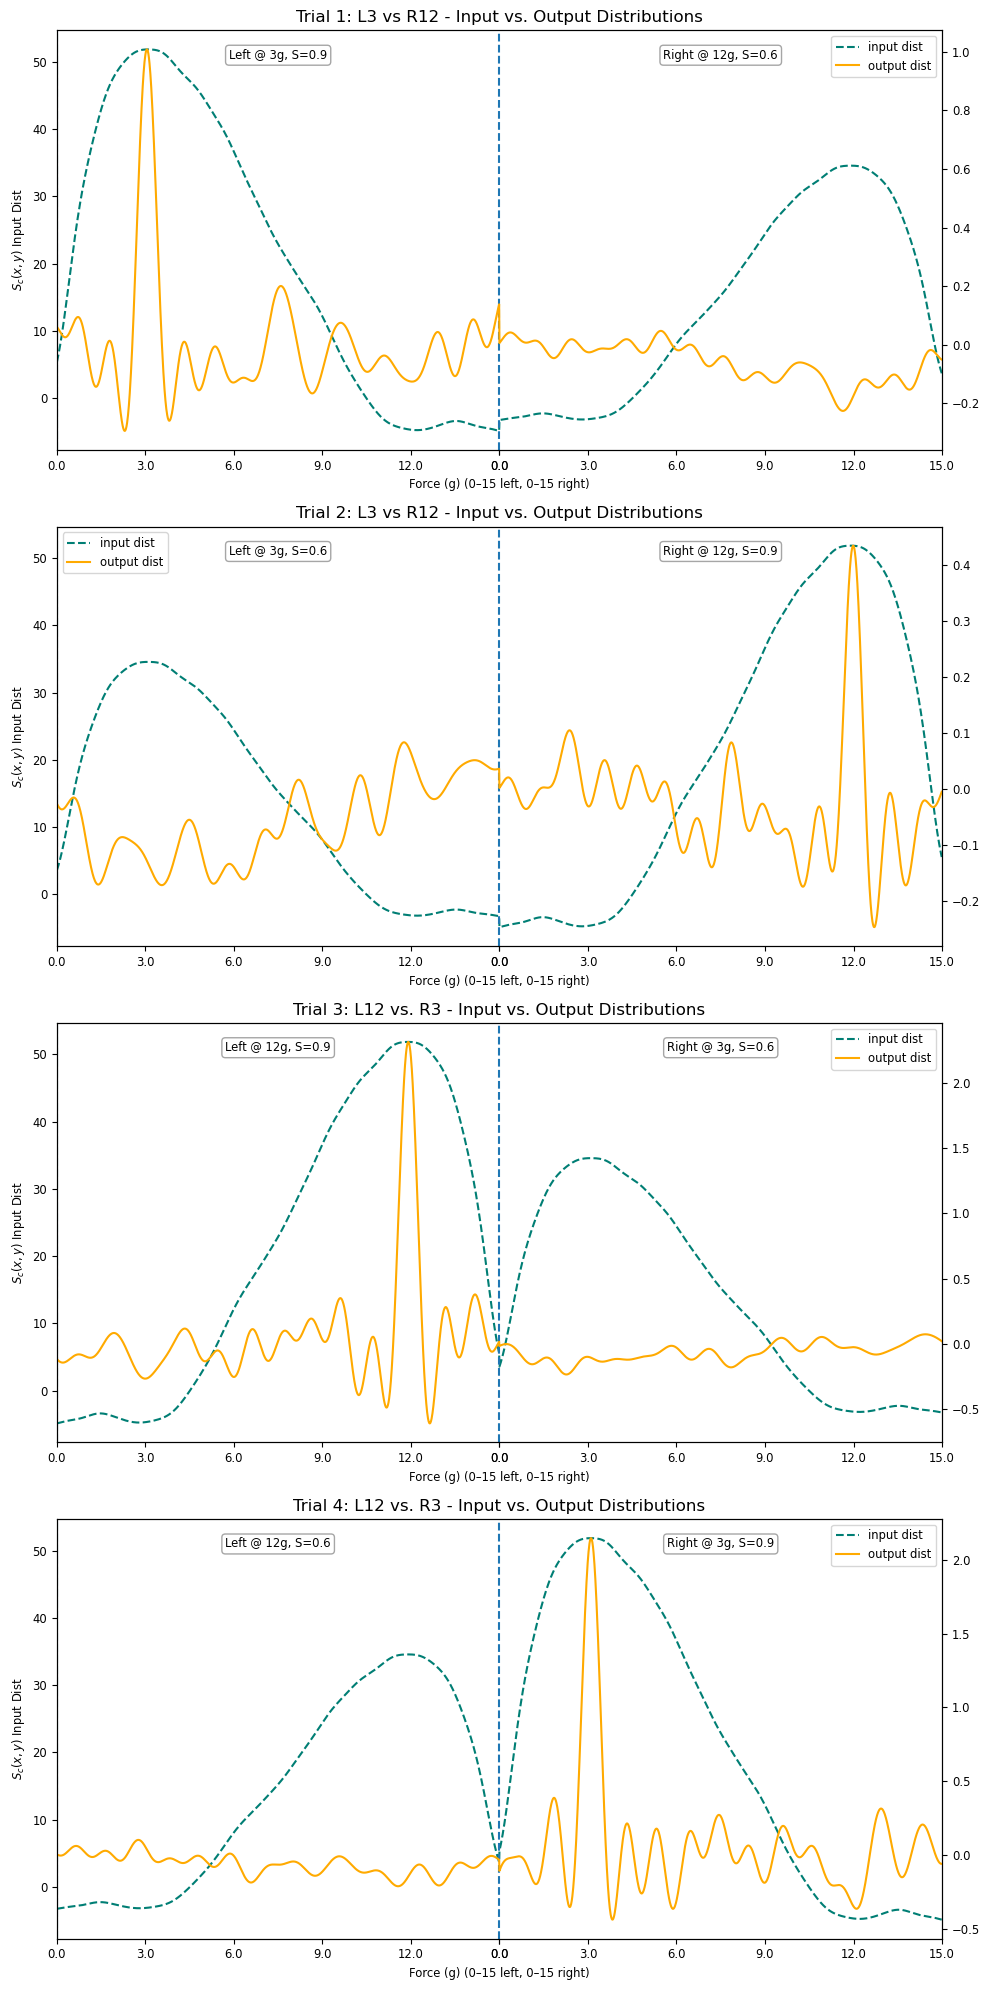

In [40]:
fig, axes = plt.subplots(4, 1, figsize=(10, 20))
plt.subplots_adjust(hspace=0.8)

# If you only have one action, axes will not be a list
if n_actions_park == 1:
    axes = [axes]

# Suppose your data length = 3000 (two chunks of 1500 each)
N = domain_force_park.shape[0]
d = np.arange(0, 2 * N)

# --- Custom ticks: first half 0–N → 0–15, second half N–2N → 0–15 ---
ticks = np.linspace(0, N, 6).astype(int)         # tick positions for half-domain
labels = np.linspace(0, 15, 6).round(1)          # labels 0..15
ticks2 = ticks + N                               # shifted ticks for second half

for i, ax in enumerate(axes):
    # primary y-axis: input distribution
    ax.plot(d, bundle_in_park[i],
            ls='--', color="#007e74", label="input dist")
    ax.set_xlabel("Force (g) (0–15 left, 0–15 right)", fontsize="small")
    ax.set_ylabel('$S_c(x,y)$ Input Dist', fontsize='small', rotation=90,
                  labelpad=10, va='center')
    ax.tick_params(axis='x', labelsize='small')
    ax.tick_params(axis='y', labelsize='small')
    ax.set_xlim(0, 2 * N)

    # ✅ Apply ticks: concatenated tick positions with repeated labels
    all_ticks = np.concatenate([ticks, ticks2])
    all_labels = [f"{lab:.1f}" for lab in labels] + [f"{lab:.1f}" for lab in labels]
    ax.set_xticks(all_ticks)
    ax.set_xticklabels(all_labels)

    # secondary y-axis: output distribution
    ax2 = ax.twinx()
    ax2.plot(d, bundle_out_park[i],
             ls='-', color="#ffaa00", label="output dist")
    ax2.tick_params(axis='y', labelsize='small')

    # combined legend
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc='best', fontsize='small')
    ax.set_title(f'Trial {i + 1}: {trial_labels[i]} - Input vs. Output Distributions')

# Add vertical lines + text
for i in range(4):
    for n in range(n_actions_park):
        xpos = n * N
        axes[i].axvline(xpos, linestyle='--')
        if n < n_actions_park - 1:
            next_xpos = (n + 1) * N
            x_text = (xpos + next_xpos) / 2
        else:
            x_text = xpos + N / 2
        y_text = axes[i].get_ylim()[1] * 0.95
        axes[i].text(
            x_text, y_text,
            f"{action_labels[i][n]}, S={salience_labels[i][n]}",
            ha='center', va='top',
            fontsize='small',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7)
        )

plt.tight_layout()
plt.savefig('./figures/park/unimodal/park_output.png')
plt.show()
